In [ ]:
import torchvision.models as models
from torch import nn
import torch
from pyprojroot import here
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import librosa
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from captum.attr import IntegratedGradients
import gc
from pyprojroot import here
from pathlib import Path
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import seaborn as sns
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
from sklearn.model_selection import train_test_split
from pytorch_grad_cam import (
    GradCAM,
    GradCAMPlusPlus,
    ScoreCAM,
    LayerCAM,
    AblationCAM,
    XGradCAM,
    EigenCAM,
    EigenGradCAM,
)

In [2]:
DEVICE = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
DEVICE

'cuda'

In [3]:
SR = 22050
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
DURATION = 5.0
BATCH_SIZE = 32
N_EPOCHS = 50
LR = 0.001

In [4]:
ROOT = here()
AUDIO_DIR = ROOT / "ESC-50" / "audio"
METADATA_PATH = ROOT / "ESC-50" / "meta" / "esc50.csv"
FIGURES_DIR = ROOT / "outputs" / "figures"
MODELS_DIR = ROOT / "models"

SPECTROGRAMS_DIR = ROOT / "data" / "spectrograms"
SPECTROGRAMS_DIR.mkdir(exist_ok=True)

meta = pd.read_csv(METADATA_PATH)

In [ ]:
def audio_to_melspectrogram(file_path):
    y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
    target_len = int(SR * DURATION)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512
    )
    mel_db = librosa.power_to_db(mel, ref=1.0)
    mel_db = np.clip(mel_db, -80, 0)
    mel_db = (mel_db + 80) / 80
    return mel_db.astype(np.float32)

In [ ]:
for _, row in tqdm(meta.iterrows(), total=len(meta)):
    out_path = SPECTROGRAMS_DIR / (row["filename"].replace(".wav", ".npy"))
    if not out_path.exists():
        mel = audio_to_melspectrogram(AUDIO_DIR / row["filename"])
        np.save(out_path, mel)

In [ ]:
class ESC50Dataset(Dataset):
    def __init__(self, meta_df, spec_dir, augment=False):
        self.meta = meta_df.reset_index(drop=True)
        self.spec_dir = Path(spec_dir)
        self.augment = augment

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        mel = np.load(self.spec_dir / (row["filename"].replace(".wav", ".npy")))
        mel = torch.tensor(mel).unsqueeze(0)

        if self.augment:
            mel = self._augment(mel)
            
        return mel, int(row["target"])

    def _augment(self, mel):
        t_start = torch.randint(0, 80, (1,)).item()
        mel[:, :, t_start : t_start + 20] = 0
        f_start = torch.randint(0, 100, (1,)).item()
        mel[:, f_start : f_start + 20, :] = 0
        return mel

In [11]:
class ConvNeXtTinyESC50(nn.Module):
    def __init__(self, n_classes=50, freeze_backbone=True):
        super().__init__()

        self.backbone = models.convnext_tiny(weights="IMAGENET1K_V1")

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.backbone.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4)

        in_features = self.backbone.classifier[2].in_features 
        
        self.backbone.classifier[2] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.backbone(x)

In [13]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [14]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            out = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
def train_fold_convnext(test_fold, meta, n_epochs_head=20, n_epochs_finetune=30):
    train_meta = meta[meta['fold'] != test_fold]
    test_meta  = meta[meta['fold'] == test_fold]

    train_ds = ESC50Dataset(train_meta, SPECTROGRAMS_DIR, augment=True)
    test_ds  = ESC50Dataset(test_meta,  SPECTROGRAMS_DIR, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = ConvNeXtTinyESC50(n_classes=50, freeze_backbone=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs_head)

    history = []
    best_acc, best_state = 0, None

    for epoch in range(1, n_epochs_head + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = eval_epoch(model, test_loader,  criterion)
        scheduler.step()
        history.append((tr_loss, tr_acc, va_loss, va_acc))

        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0:
            print(f"  Epoka {epoch:3d}, tr_acc {tr_acc:.4f}, val_acc {va_acc:.4f}")

    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs_finetune)

    for epoch in range(1, n_epochs_finetune + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = eval_epoch(model, test_loader,  criterion)
        scheduler.step()
        history.append((tr_loss, tr_acc, va_loss, va_acc))

        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0:
            print(f"  Epoka {epoch:3d}, tr_acc {tr_acc:.4f}, val_acc {va_acc:.4f}")

    model.load_state_dict(best_state)
    
    return model, history, best_acc

In [ ]:
convnext_scores    = []
convnext_histories = []

for fold in range(1, 6):
    print(f"\nFold {fold}")
    model_fold, history, best_acc = train_fold_convnext(fold, meta, n_epochs_head=20, n_epochs_finetune=50)
    convnext_scores.append(best_acc)
    convnext_histories.append(history)
    torch.save(model_fold.state_dict(), MODELS_DIR / f"convnext_fold{fold}.pt")

In [7]:
best_fold = 4

# Fold 1: 0.7275
# Fold 2: 0.7525
# Fold 3: 0.7625
# Fold 4: 0.7725
# Fold 5: 0.7075

In [8]:
print(meta[['target', 'category']].drop_duplicates().sort_values('target').to_string(index=False))

 target         category
      0              dog
      1          rooster
      2              pig
      3              cow
      4             frog
      5              cat
      6              hen
      7          insects
      8            sheep
      9             crow
     10             rain
     11        sea_waves
     12   crackling_fire
     13         crickets
     14   chirping_birds
     15      water_drops
     16             wind
     17    pouring_water
     18     toilet_flush
     19     thunderstorm
     20      crying_baby
     21         sneezing
     22         clapping
     23        breathing
     24         coughing
     25        footsteps
     26         laughing
     27   brushing_teeth
     28          snoring
     29 drinking_sipping
     30  door_wood_knock
     31      mouse_click
     32  keyboard_typing
     33 door_wood_creaks
     34      can_opening
     35  washing_machine
     36   vacuum_cleaner
     37      clock_alarm
     38       clock_tick


In [9]:
ig_convnext = IntegratedGradients(lambda x: model_convnext(x))

def calc_ig_convnext(mel_tensor, target_class):
    input_tensor = mel_tensor.unsqueeze(0).unsqueeze(0).to(DEVICE).requires_grad_(True)
    baseline = torch.zeros_like(input_tensor)
    
    attr = ig_convnext.attribute(
        input_tensor,
        baseline,
        target=target_class,
        n_steps=50,
        internal_batch_size=4,
        return_convergence_delta=False,
    )
    
    attr = attr.squeeze().detach().cpu()
    attr = attr.abs()
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    
    return attr.numpy()

In [12]:
model_convnext = ConvNeXtTinyESC50(n_classes=50).to(DEVICE)
model_convnext.load_state_dict(
    torch.load(MODELS_DIR / f"convnext_fold{best_fold}.pt", map_location=DEVICE)
)
model_convnext.eval()

target_layer_convnext = [model_convnext.backbone.features[-1][-1].block[0]]

cams_convnext = {
    "GradCAM++": GradCAMPlusPlus(model=model_convnext, target_layers=target_layer_convnext),
    "LayerCAM":  LayerCAM(model=model_convnext,        target_layers=target_layer_convnext),
    "ScoreCAM":  ScoreCAM(model=model_convnext,        target_layers=target_layer_convnext),
    # "AblationCAM": AblationCAM(model=model_convnext,    target_layers=target_layer_convnext),
    "XGradCAM":   XGradCAM(model=model_convnext,      target_layers=target_layer_convnext),
    # "EigenCAM":   EigenCAM(model=model_convnext,      target_layers=target_layer_convnext),
}

100%|██████████| 48/48 [00:03<00:00, 15.36it/s]


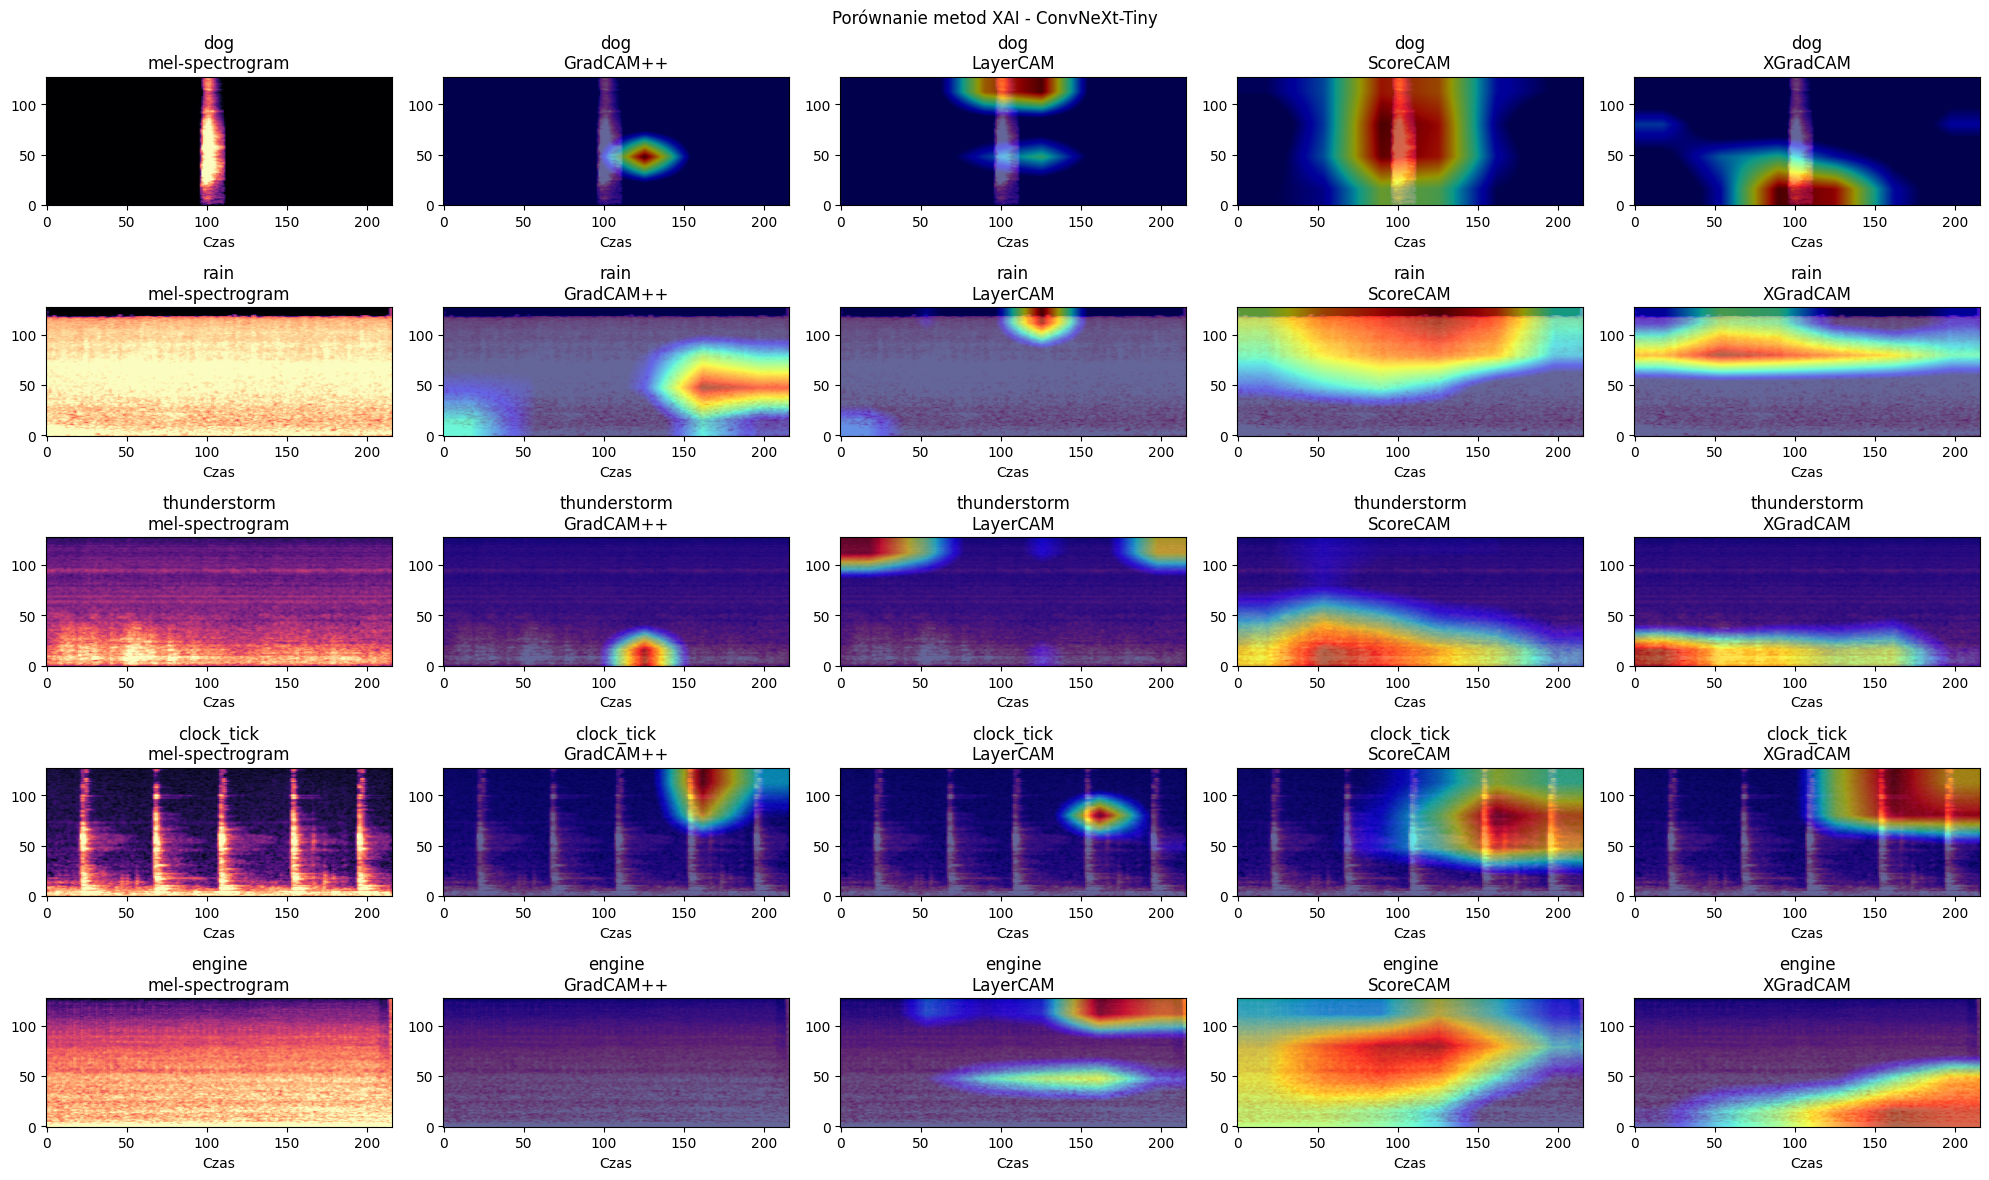

In [13]:
examples = [
    ("dog", 0, meta[meta["category"] == "dog"].iloc[0]["filename"]),
    ("rain", 10, meta[meta["category"] == "rain"].iloc[0]["filename"]),
    ("thunderstorm", 19, meta[meta["category"] == "thunderstorm"].iloc[0]["filename"]),
    ("clock_tick", 38, meta[meta["category"] == "clock_tick"].iloc[0]["filename"]),
    ("engine", 44, meta[meta["category"] == "engine"].iloc[0]["filename"]),
]

fig, axes = plt.subplots(5, len(cams_convnext) + 1, figsize=(20, 12))

for i, (label, target_id, fname) in enumerate(examples):
    mel = np.load(SPECTROGRAMS_DIR / fname.replace(".wav", ".npy"))
    input_tensor = torch.tensor(mel).unsqueeze(0).unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(target_id)]

    axes[i, 0].imshow(mel, origin="lower", aspect="auto", cmap="magma")
    axes[i, 0].set_title(f"{label}\nmel-spectrogram")
    axes[i, 0].set_xlabel("Czas")

    for j, (cam_name, cam) in enumerate(cams_convnext.items()):
        heatmap = cam(input_tensor=input_tensor, targets=targets)[0]
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 0.000001)

        axes[i, j + 1].imshow(mel, origin="lower", aspect="auto", cmap="magma")
        axes[i, j + 1].imshow(
            heatmap,
            origin="lower",
            aspect="auto",
            cmap="jet",
            alpha=0.6,
            vmin=0.2,
            vmax=1.0,
        )
        axes[i, j + 1].set_title(f"{label}\n{cam_name}")
        axes[i, j + 1].set_xlabel("Czas")

plt.suptitle("Porównanie metod XAI - ConvNeXt-Tiny")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cam_convnext_comparison.png", dpi=150)
plt.show()

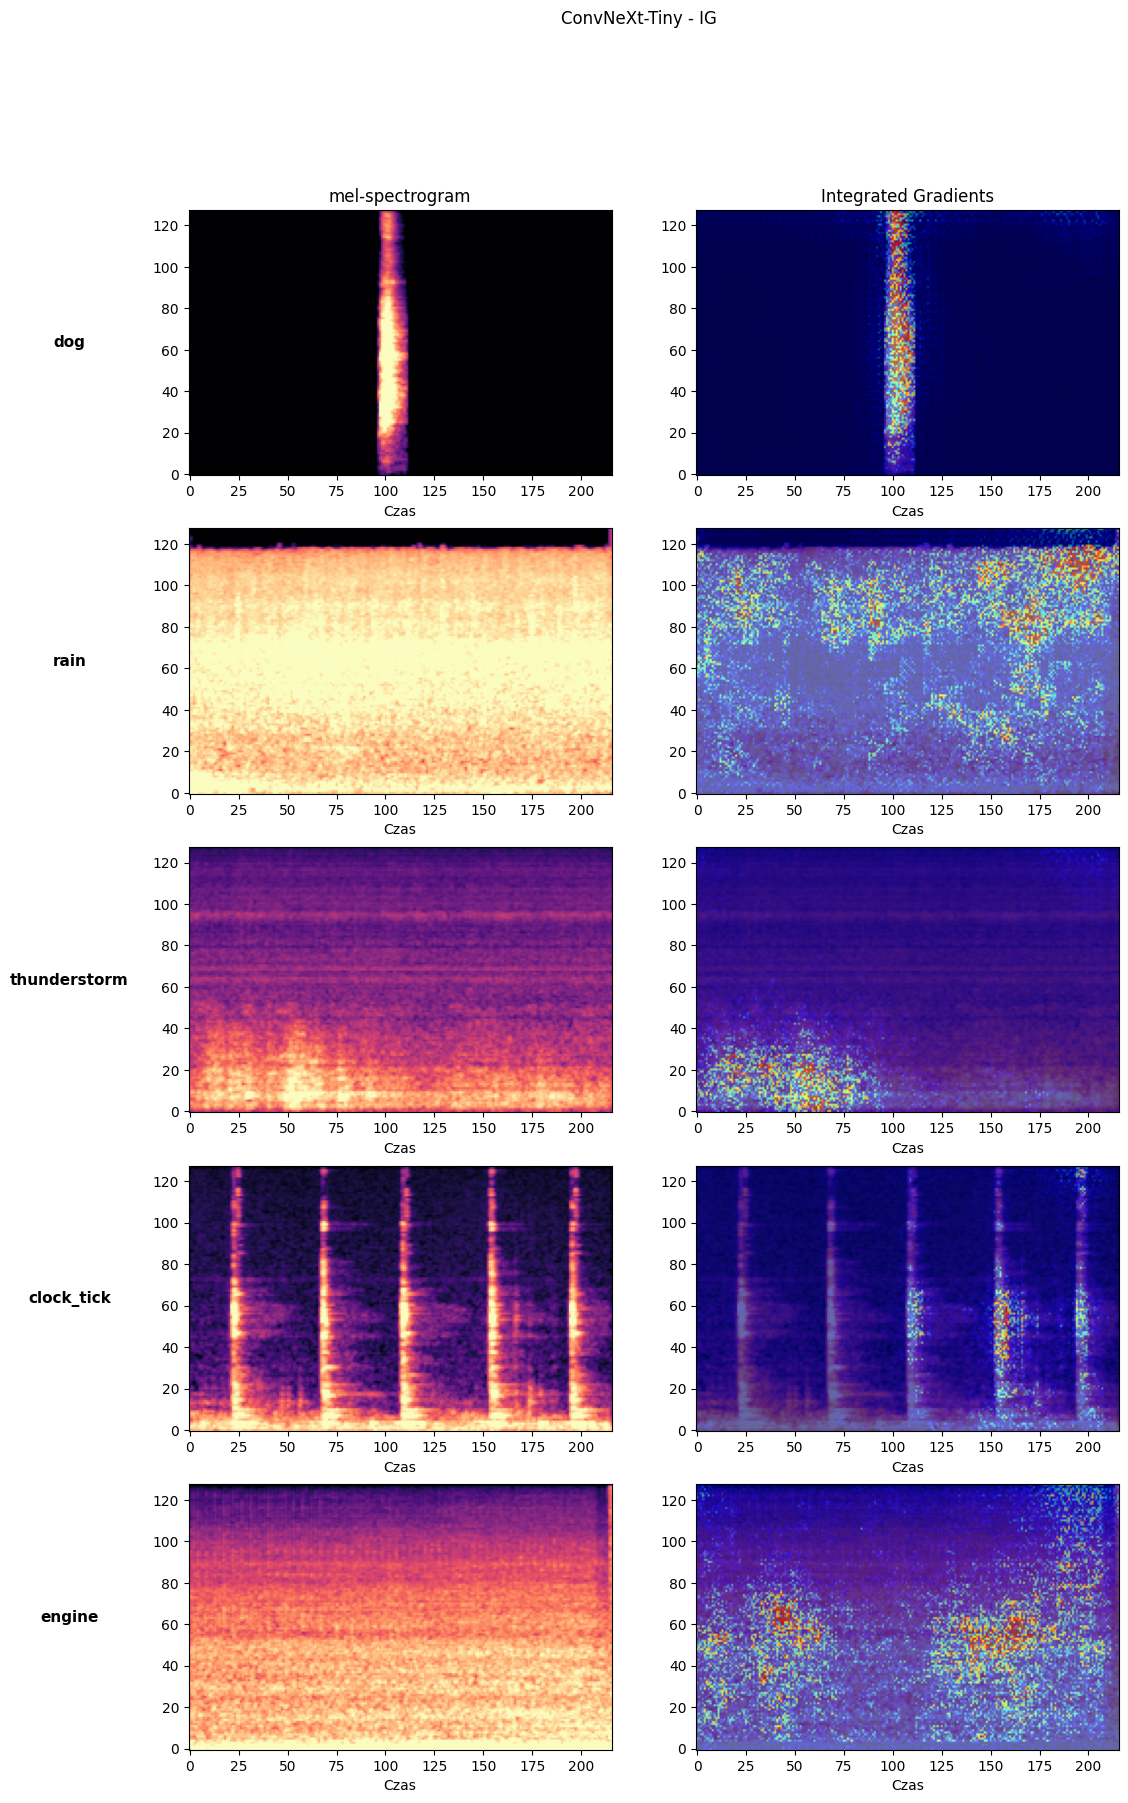

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(12, 20))

for i, (label, target_id, fname) in enumerate(examples):
    mel = np.load(SPECTROGRAMS_DIR / fname.replace(".wav", ".npy"))
    
    ig_attr = calc_ig_convnext(torch.tensor(mel), target_id)
    
    axes[i, 0].imshow(mel, origin="lower", aspect="auto", cmap="magma")
    axes[i, 0].set_ylabel(label, fontsize=11, fontweight='bold',
                          rotation=0, labelpad=60, va='center')
    axes[i, 0].set_xlabel("Czas")
    
    axes[i, 1].imshow(mel, origin="lower", aspect="auto", cmap="magma")
    axes[i, 1].imshow(ig_attr, origin="lower", aspect="auto",
                      cmap="jet", alpha=0.6, vmin=0.0, vmax=0.3)
    axes[i, 1].set_xlabel("Czas")

axes[0, 0].set_title("mel-spectrogram")
axes[0, 1].set_title("Integrated Gradients")

plt.suptitle("ConvNeXt-Tiny - IG")
# plt.tight_layout()
plt.savefig(FIGURES_DIR / "cam_convnext_ig.png", dpi=150)
plt.show()